In [ ]:
import os
import subprocess
import sys
import time
import warnings

warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules


def pip_install(packages, quiet=True):
    """Install packages with pip from inside the notebook process."""
    cmd = [sys.executable, "-m", "pip", "install", "--upgrade"]
    if quiet:
        cmd.append("-q")
    subprocess.run(cmd + list(packages), check=False)


try:
    import geoai
except ImportError:
    print(">>> Installing geoai-py and friends (takes ~2-4 minutes on Colab)...")
    pip_install(
        [
            "geoai-py",
            "segmentation-models-pytorch",
            "buildingregulariser",
        ]
    )
    try:
        import geoai
    except Exception as e:
        raise SystemExit(
            f"Import failed after install ({e}).\n"
            "=> Runtime > Restart session, then re-run this cell. "
            "The install is cached, so it will be fast the second time."
        )

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
from rasterio.plot import plotting_extent
from IPython.display import display

print(f"geoai        : {geoai.__version__}")
print(f"torch        : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
else:
    print("!! No GPU detected. Training will still run but be much slower.")
    print("   Colab: Runtime > Change runtime type > Hardware accelerator > T4 GPU")

DEVICE = geoai.get_device()
print(f"geoai device : {DEVICE}")


CFG = {

    "tile_size": 512,
    "stride": 256,
    "buffer_radius": 0,

    "architecture": "unet",
    "encoder": "resnet34",
    "encoder_weights": "imagenet",
    "num_channels": 3,
    "num_classes": 2,
    "batch_size": 8,
    "num_epochs": 12,
    "learning_rate": 1e-3,
    "val_split": 0.2,

    "window_size": 512,
    "overlap": 256,

    "run_zero_shot": True,
    "run_pretrained": True,
    "run_real_aoi": False,
}

WORK = "/content/geoai_tutorial" if IN_COLAB else os.path.abspath("geoai_tutorial")
os.makedirs(WORK, exist_ok=True)
os.chdir(WORK)
print(f"working dir  : {WORK}")


def banner(text):
    print("\n" + "=" * 92 + f"\n  {text}\n" + "=" * 92)


def timed(fn, label):
    """Run fn(), report wall time, never let one step kill the notebook."""
    banner(label)
    t0 = time.time()
    try:
        out = fn()
        print(f"\n[OK] {label}  —  {time.time() - t0:.1f}s")
        return out
    except Exception as exc:
        import traceback

        print(f"\n[SKIPPED] {label}\n{type(exc).__name__}: {exc}")
        traceback.print_exc(limit=3)
        return None


HF = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main"
train_raster_url = f"{HF}/naip_rgb_train.tif"
train_vector_url = f"{HF}/naip_train_buildings.geojson"
test_raster_url = f"{HF}/naip_test.tif"


def step1():
    train_raster = geoai.download_file(train_raster_url)
    train_vector = geoai.download_file(train_vector_url)
    test_raster = geoai.download_file(test_raster_url)
    for p in (train_raster, train_vector, test_raster):
        print(f"  {os.path.getsize(p) / 1e6:8.2f} MB  {p}")
    return train_raster, train_vector, test_raster


paths = timed(step1, "STEP 1 — Downloading sample NAIP imagery and building labels")
TRAIN_RASTER, TRAIN_VECTOR, TEST_RASTER = paths

In [ ]:
def step2():

    info = geoai.get_raster_info(TRAIN_RASTER)
    for k, v in info.items():
        print(f"  {k:<16}: {v}")

    print("\n--- per-band statistics ---")
    print(geoai.get_raster_stats(TRAIN_RASTER))


    print("\n--- vector info ---")
    vinfo = geoai.get_vector_info(TRAIN_VECTOR)
    for k, v in vinfo.items():
        print(f"  {k:<16}: {v}")

    gdf = gpd.read_file(TRAIN_VECTOR)
    print(f"\n  {len(gdf)} training buildings | CRS {gdf.crs}")
    print(gdf.head(3))


    geoai.view_vector(
        gdf,
        raster_path=TRAIN_RASTER,
        outline_only=True,
        edge_color="yellow",
        outline_linewidth=0.8,
        figsize=(11, 11),
        title="NAIP training scene + building footprints",
    )


    try:
        display(geoai.view_vector_interactive(TRAIN_VECTOR, layer_name="Buildings"))
    except Exception as e:
        print(f"  (interactive map unavailable here: {e})")
    return gdf


LABELS_GDF = timed(step2, "STEP 2 — Inspecting raster + vector data")


TILES_DIR = os.path.join(WORK, "tiles")


def step3():
    stats = geoai.export_geotiff_tiles(
        in_raster=TRAIN_RASTER,
        out_folder=TILES_DIR,
        in_class_data=TRAIN_VECTOR,
        tile_size=CFG["tile_size"],
        stride=CFG["stride"],
        buffer_radius=CFG["buffer_radius"],
        all_touched=True,
        skip_empty_tiles=False,
        quiet=False,
    )
    n_img = len(os.listdir(f"{TILES_DIR}/images"))
    n_lbl = len(os.listdir(f"{TILES_DIR}/labels"))
    print(f"\n  chips: {n_img} images / {n_lbl} masks")
    if isinstance(stats, dict):
        tot = max(stats.get("total_tiles", n_img), 1)
        print(f"  tiles containing buildings: {stats.get('tiles_with_features')} "
              f"({100 * stats.get('tiles_with_features', 0) / tot:.1f}%)")
        print(f"  foreground pixels: {stats.get('feature_pixels'):,}")


    geoai.display_training_tiles(TILES_DIR, num_tiles=6, figsize=(18, 6))
    return stats


TILE_STATS = timed(step3, "STEP 3 — Exporting image chips and label masks")

In [ ]:
MODEL_DIR = os.path.join(WORK, "models_unet")
BEST_MODEL = os.path.join(MODEL_DIR, "best_model.pth")


def step4():
    geoai.train_segmentation_model(
        images_dir=f"{TILES_DIR}/images",
        labels_dir=f"{TILES_DIR}/labels",
        output_dir=MODEL_DIR,
        architecture=CFG["architecture"],
        encoder_name=CFG["encoder"],
        encoder_weights=CFG["encoder_weights"],
        num_channels=CFG["num_channels"],
        num_classes=CFG["num_classes"],
        batch_size=CFG["batch_size"],
        num_epochs=CFG["num_epochs"],
        learning_rate=CFG["learning_rate"],
        val_split=CFG["val_split"],
        save_best_only=True,
        early_stopping_patience=5,
        verbose=True,
    )
    print(f"\n  best checkpoint: {BEST_MODEL}")
    print(f"  size: {os.path.getsize(BEST_MODEL) / 1e6:.1f} MB")
    return BEST_MODEL


timed(step4, f"STEP 4 — Training {CFG['architecture']}/{CFG['encoder']} "
              f"for {CFG['num_epochs']} epochs")


def step5():
    hist_path = os.path.join(MODEL_DIR, "training_history.pth")
    geoai.plot_performance_metrics(
        history_path=hist_path,
        figsize=(15, 5),
        verbose=True,
        save_path=os.path.join(WORK, "training_curves.png"),
    )
    h = torch.load(hist_path, weights_only=False)
    best_ep = int(np.argmax(h["val_iou"])) + 1
    print(f"\n  best val IoU {max(h['val_iou']):.4f} at epoch {best_ep}")
    print("  Reading the curves: val loss rising while train loss falls => overfitting;")
    print("  both flat and high => underfitting (more epochs, bigger encoder, or more chips).")


timed(step5, "STEP 5 — Training diagnostics")

In [ ]:
PRED_MASK = os.path.join(WORK, "test_prediction.tif")
PRED_PROB = os.path.join(WORK, "test_probability.tif")


def step6():
    geoai.semantic_segmentation(
        input_path=TEST_RASTER,
        output_path=PRED_MASK,
        model_path=BEST_MODEL,
        architecture=CFG["architecture"],
        encoder_name=CFG["encoder"],
        num_channels=CFG["num_channels"],
        num_classes=CFG["num_classes"],
        window_size=CFG["window_size"],
        overlap=CFG["overlap"],
        batch_size=4,
        probability_path=PRED_PROB,
    )
    geoai.print_raster_info(PRED_MASK, show_preview=False)
    geoai.plot_prediction_comparison(
        original_image=TEST_RASTER,
        prediction_image=PRED_MASK,
        titles=["NAIP test scene", "Predicted building mask"],
        figsize=(16, 8),
        prediction_colormap="viridis",
        save_path=os.path.join(WORK, "prediction_comparison.png"),
    )
    with rasterio.open(PRED_MASK) as src:
        m = src.read(1)
        px = float(abs(src.transform.a) * abs(src.transform.e))
    print(f"  predicted building pixels: {int((m > 0).sum()):,} "
          f"({100 * (m > 0).mean():.2f}% of scene, ~{(m > 0).sum() * px:,.0f} m2)")


timed(step6, "STEP 6 — Sliding-window inference on the test scene")


VEC_RAW = os.path.join(WORK, "buildings_raw.geojson")
VEC_ORTHO = os.path.join(WORK, "buildings_orthogonal.geojson")
VEC_FINAL = os.path.join(WORK, "buildings_final.geojson")


def step7():

    grouped = geoai.region_groups(
        PRED_MASK,
        connectivity=2,
        min_size=50,
        out_image=os.path.join(WORK, "test_prediction_cleaned.tif"),
    )
    clean_mask = os.path.join(WORK, "test_prediction_cleaned.tif")


    raw = geoai.raster_to_vector(
        clean_mask,
        output_path=VEC_RAW,
        threshold=0,
        min_area=15,
        simplify_tolerance=0.5,
    )
    print(f"  raw polygons        : {len(raw)}")


    ortho = geoai.orthogonalize(
        input_path=clean_mask,
        output_path=VEC_ORTHO,
        epsilon=1.5,
        min_area=15,
    )
    print(f"  orthogonalized      : {len(ortho)}")


    final = geoai.regularization(ortho, angle_tolerance=12, simplify_tolerance=0.4)
    final = geoai.add_geometric_properties(
        final, properties=["area", "perimeter", "solidity", "elongation", "orientation"]
    )
    final.to_file(VEC_FINAL, driver="GeoJSON")
    print(f"  final footprints    : {len(final)}")
    print(final.head())
    if "area" in final.columns:
        print("\n  footprint area stats (m2):")
        print(final["area"].describe().round(1).to_string())


    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    with rasterio.open(TEST_RASTER) as src:
        rgb = src.read([1, 2, 3]).transpose(1, 2, 0)
        rgb = np.clip(rgb / np.percentile(rgb, 99), 0, 1)
        ext = plotting_extent(src)
    for ax, g, t in zip(axes, [raw, final], ["Raw polygonization", "Orthogonalized + regularized"]):
        ax.imshow(rgb, extent=ext)
        g.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.1)
        ax.set_title(t)
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    try:
        display(geoai.view_vector_interactive(VEC_FINAL, layer_name="Predicted buildings"))
    except Exception:
        pass
    return final


FINAL_GDF = timed(step7, "STEP 7 — Vectorizing and regularizing the predicted footprints")

In [ ]:
def step8():
    gt_raster = os.path.join(WORK, "train_gt_mask.tif")
    geoai.vector_to_raster(
        vector_path=TRAIN_VECTOR,
        output_path=gt_raster,
        reference_raster=TRAIN_RASTER,
        fill_value=0,
        all_touched=True,
        dtype=np.uint8,
    )
    train_pred = os.path.join(WORK, "train_prediction.tif")
    geoai.semantic_segmentation(
        input_path=TRAIN_RASTER,
        output_path=train_pred,
        model_path=BEST_MODEL,
        architecture=CFG["architecture"],
        encoder_name=CFG["encoder"],
        num_channels=CFG["num_channels"],
        num_classes=CFG["num_classes"],
        window_size=CFG["window_size"],
        overlap=CFG["overlap"],
        quiet=True,
    )
    metrics = geoai.calc_segmentation_metrics(
        ground_truth=gt_raster,
        prediction=train_pred,
        num_classes=2,
        metrics=["iou", "f1"],
    )
    print("\n  --- pixel-wise metrics (class 0 = background, class 1 = building) ---")
    for k, v in metrics.items():
        print(f"  {k:<10}: {np.round(v, 4)}")
    print("\n  Building-class IoU is the number that matters; background IoU is inflated")
    print("  by the huge negative class and always looks great.")

    geoai.plot_prediction_comparison(
        original_image=TRAIN_RASTER,
        prediction_image=train_pred,
        ground_truth_image=gt_raster,
        titles=["Imagery", "Prediction", "Ground truth"],
        figsize=(18, 6),
        save_path=os.path.join(WORK, "accuracy_comparison.png"),
    )
    return metrics


METRICS = timed(step8, "STEP 8 — Quantitative accuracy assessment")


def step9():
    if not CFG["run_zero_shot"]:
        print("  disabled in CFG"); return


    chip = os.path.join(WORK, "test_chip.tif")
    with rasterio.open(TEST_RASTER) as src:
        b = src.bounds
        cx, cy = (b.left + b.right) / 2, (b.bottom + b.top) / 2
        half = min((b.right - b.left), (b.top - b.bottom)) / 6
        bbox = [cx - half, cy - half, cx + half, cy + half]
    geoai.clip_raster_by_bbox(TEST_RASTER, chip, bbox=bbox, bbox_type="geo")
    print(f"  clipped chip: {chip}")

    sam = geoai.GroundedSAM(
        detector_id="IDEA-Research/grounding-dino-tiny",
        segmenter_id="facebook/sam-vit-base",
        tile_size=1024,
        overlap=128,
        threshold=0.3,
    )
    out_mask = os.path.join(WORK, "zeroshot_mask.tif")
    gdf = sam.segment_image(
        input_path=chip,
        output_path=out_mask,
        text_prompts=["building", "house", "rooftop"],
        polygon_refinement=True,
        export_polygons=True,
        min_polygon_area=30,
        simplify_tolerance=1.5,
    )
    geoai.plot_prediction_comparison(
        original_image=chip,
        prediction_image=out_mask,
        titles=["Chip", "Zero-shot: 'building / house / rooftop'"],
        figsize=(14, 7),
        prediction_colormap="viridis",
    )
    print(f"  zero-shot objects found: {len(gdf) if gdf is not None else 0}")
    geoai.empty_cache()


timed(step9, "STEP 9 — Zero-shot text-prompted segmentation (Grounding DINO + SAM)")

>>> Installing geoai-py and friends (takes ~2-4 minutes on Colab)...
geoai        : 0.42.0
torch        : 2.11.0+cu128
CUDA available: True
GPU          : Tesla T4
geoai device : cuda
working dir  : /content/geoai_tutorial

  STEP 1 — Downloading sample NAIP imagery and building labels


      9.31 MB  naip_rgb_train.tif
      0.34 MB  naip_train_buildings.geojson
     20.61 MB  naip_test.tif

[OK] STEP 1 — Downloading sample NAIP imagery and building labels  —  2.9s

  STEP 2 — Inspecting raster + vector data
  driver          : GTiff
  width           : 2503
  height          : 1126
  count           : 3
  dtype           : uint8
  crs             : EPSG:26911
  transform       : | 0.60, 0.00, 454780.80|
| 0.00,-0.60, 5278242.60|
| 0.00, 0.00, 1.00|
  bounds          : BoundingBox(left=454780.8, bottom=5277567.0, right=456282.6, top=5278242.6)
  resolution      : (0.6, 0.6)
  nodata          : None
  band_stats      : [{'band': 1, 'min': 12.0, 'max': 251.0, 'mean': 150.6730747259594, 'std': 48.01908734374099}, {'band': 2, 'min': 49.0, 'max': 251.0, 'mean': 141.92468895229808, 'std': 43.46595463573497}, {'band': 3, 'min': 53.0, 'max': 251.0, 'mean': 120.89909373405554, 'std': 41.78086244480775}]

--- per-band statistics ---
{'min': [12.0, 49.0, 53.0], 'max': [251.0, 2


[OK] STEP 2 — Inspecting raster + vector data  —  4.7s

  STEP 3 — Exporting image chips and label masks


Generating tiles:   0%|          | 0/36 [00:00<?, ?it/s]


  chips: 36 images / 36 masks
  tiles containing buildings: 36 (100.0%)
  foreground pixels: 1,684,620


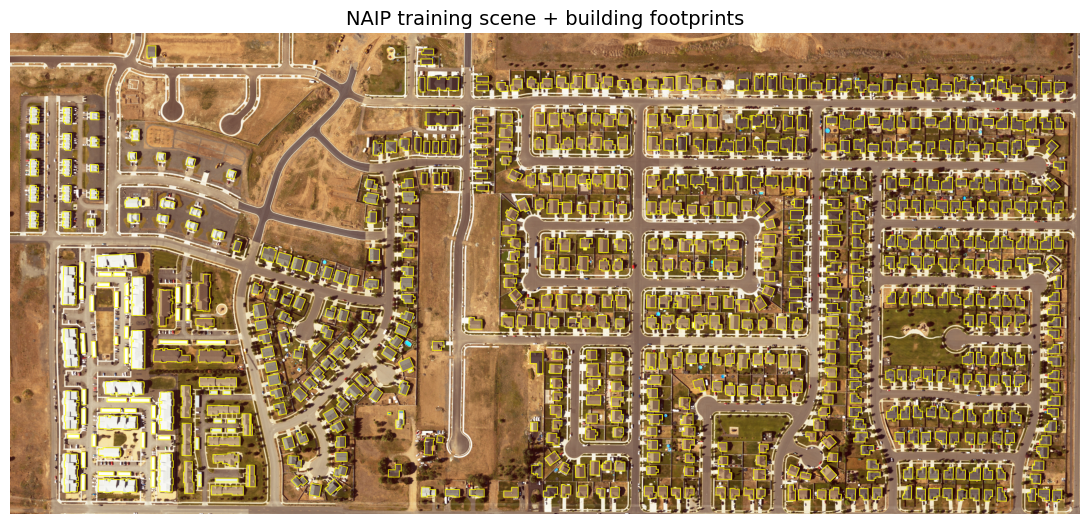

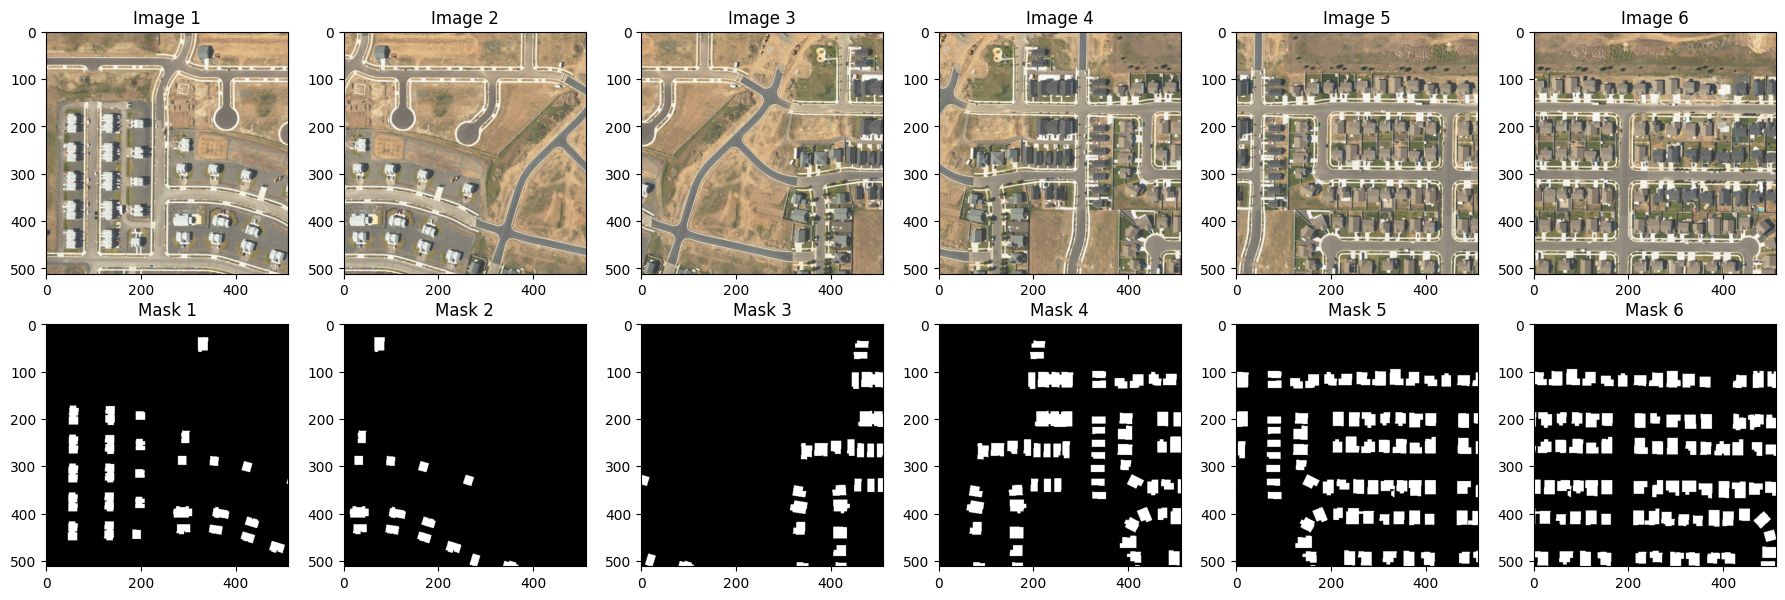


[OK] STEP 3 — Exporting image chips and label masks  —  15.8s

  STEP 4 — Training unet/resnet34 for 12 epochs


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            


  best checkpoint: /content/geoai_tutorial/models_unet/best_model.pth
  size: 97.9 MB

[OK] STEP 4 — Training unet/resnet34 for 12 epochs  —  59.4s

  STEP 5 — Training diagnostics


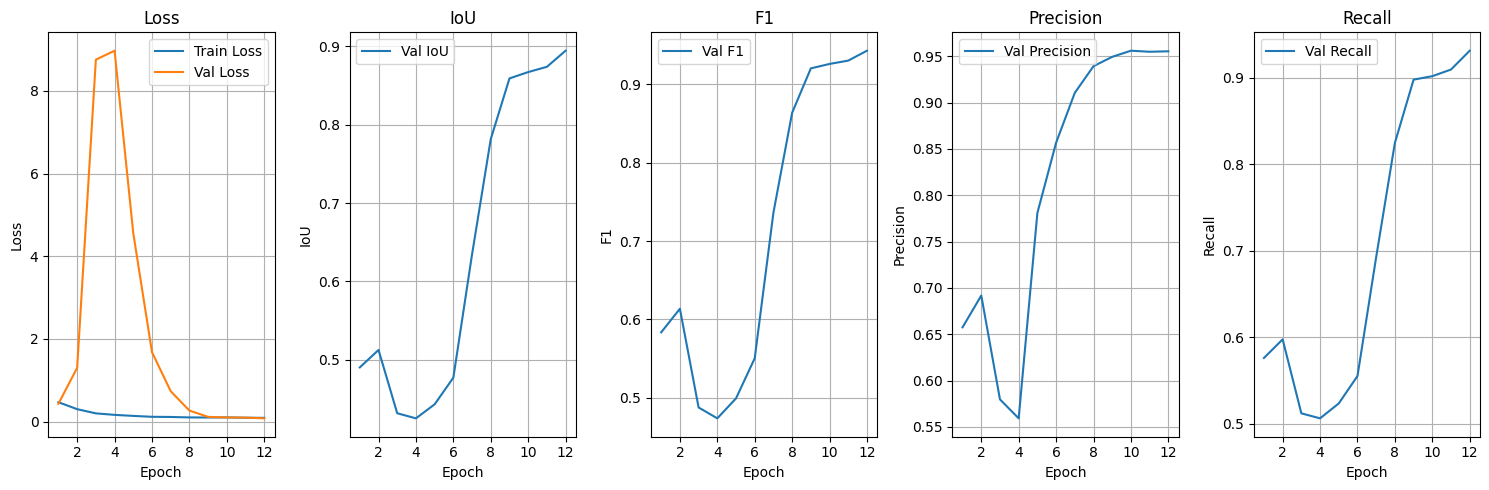


[SKIPPED] STEP 5 — Training diagnostics
KeyError: 'val_iou'

  STEP 6 — Sliding-window inference on the test scene


Traceback (most recent call last):
  File "/tmp/ipykernel_484/3336621713.py", line 127, in timed
    out = fn()
          ^^^^
  File "/tmp/ipykernel_484/3336621713.py", line 293, in step5
    best_ep = int(np.argmax(h["val_iou"])) + 1
                            ~^^^^^^^^^^^
KeyError: 'val_iou'


  0%|          | 0/65 [00:00<?, ?it/s]

===== RASTER INFORMATION: /content/geoai_tutorial/test_prediction.tif =====
Driver: GTiff
Dimensions: 3382 x 1347 pixels
Number of bands: 1
Data type: uint8
Coordinate Reference System: EPSG:26911
Georeferenced Bounds: BoundingBox(left=454641.6, bottom=5276774.4, right=456670.8, top=5277582.6)
Pixel Resolution: 0.6, 0.6
NoData Value: None
----- Band Statistics -----
Band 1:
  Min: 0.00
  Max: 1.00
  Mean: 0.10
  Std Dev: 0.30


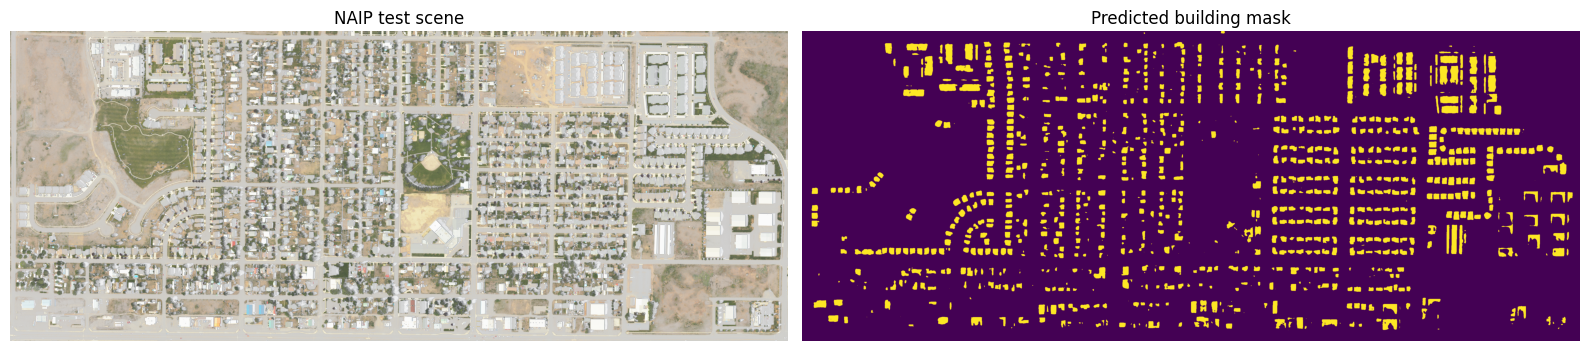

  predicted building pixels: 456,899 (10.03% of scene, ~164,484 m2)

[OK] STEP 6 — Sliding-window inference on the test scene  —  9.1s

  STEP 7 — Vectorizing and regularizing the predicted footprints

[SKIPPED] STEP 7 — Vectorizing and regularizing the predicted footprints
AttributeError: '<class 'skimage.measure._regionprops.RegionProperties'>' object has no attribute 'diameter_areagth'

  STEP 8 — Quantitative accuracy assessment


Traceback (most recent call last):
  File "/tmp/ipykernel_484/3336621713.py", line 127, in timed
    out = fn()
          ^^^^
  File "/tmp/ipykernel_484/3336621713.py", line 357, in step7
    grouped = geoai.region_groups(
              ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/geoai/utils/geometry.py", line 497, in region_groups
    props = measure.regionprops_table(
            ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: '<class 'skimage.measure._regionprops.RegionProperties'>' object has no attribute 'diameter_areagth'



  --- pixel-wise metrics (class 0 = background, class 1 = building) ---
  iou       : [0.9647 0.8273]
  mean_iou  : 0.896
  f1        : [0.982  0.9055]
  mean_f1   : 0.9438

  Building-class IoU is the number that matters; background IoU is inflated
  by the huge negative class and always looks great.


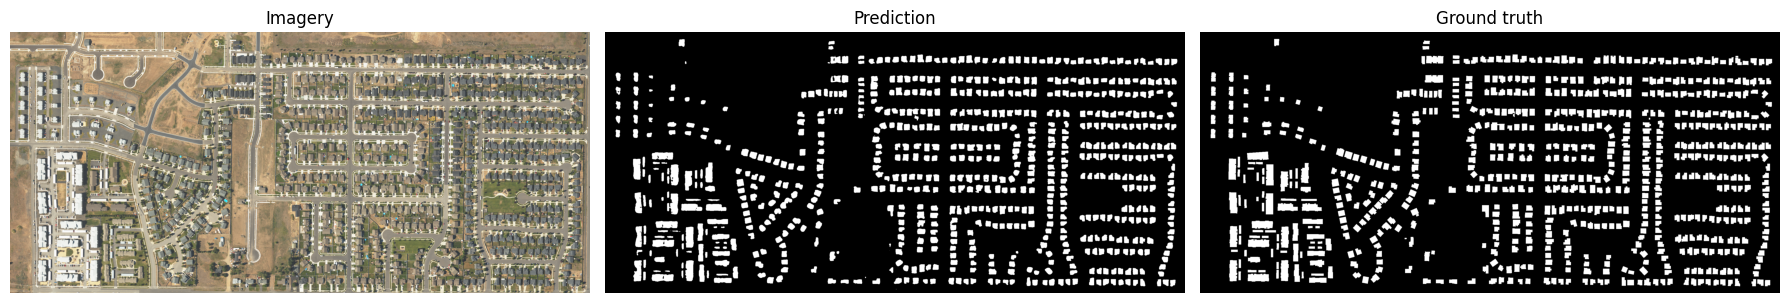


[OK] STEP 8 — Quantitative accuracy assessment  —  7.2s

  STEP 9 — Zero-shot text-prompted segmentation (Grounding DINO + SAM)
  clipped chip: /content/geoai_tutorial/test_chip.tif


config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  689MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

Processing tiles:   0%|          | 0/1 [00:00<?, ?it/s]

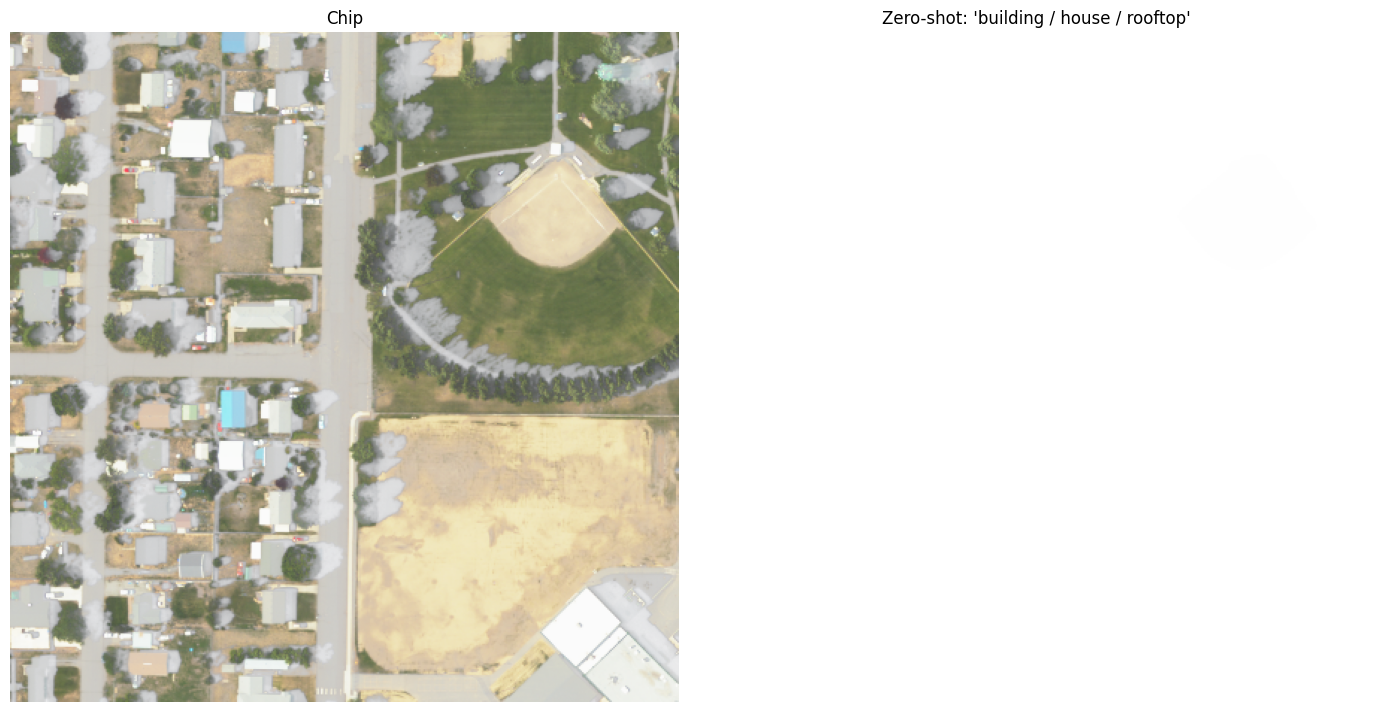

  zero-shot objects found: 2

[OK] STEP 9 — Zero-shot text-prompted segmentation (Grounding DINO + SAM)  —  35.7s

  STEP 10 — Pretrained Mask R-CNN instance segmentation


building_footprints_usa.pth: reconstructing file:   0%|          |  0.00B /  176MB            

building_footprints_usa.pth: downloading bytes:           |  0.00B            

  0%|          | 0/9 [00:00<?, ?it/s]

  building instances: 961


  0%|          | 0/961 [00:00<?, ?it/s]


[OK] STEP 10 — Pretrained Mask R-CNN instance segmentation  —  74.9s

  STEP 11 — (optional) Real AOI: Planetary Computer NAIP + Overture Maps labels
  disabled (set CFG['run_real_aoi'] = True to run; needs open internet)

[OK] STEP 11 — (optional) Real AOI: Planetary Computer NAIP + Overture Maps labels  —  0.0s

  STEP 12 — Results summary
  artifacts produced:
        3.34 MB  accuracy_comparison.png
        1.08 MB  buildings_maskrcnn.geojson
        0.33 MB  buildings_maskrcnn_regularized.geojson
        9.31 MB  naip_rgb_train.tif
       20.61 MB  naip_test.tif
        0.34 MB  naip_train_buildings.geojson
        4.43 MB  prediction_comparison.png
        0.81 MB  test_chip.tif
        4.56 MB  test_prediction.tif
       36.45 MB  test_probability.tif
        2.83 MB  train_gt_mask.tif
        2.83 MB  train_prediction.tif
        0.12 MB  training_curves.png
        0.81 MB  zeroshot_mask.tif
        0.02 MB  zeroshot_mask_polygons.geojson

  bundle: /content/geoai_tutorial/ge

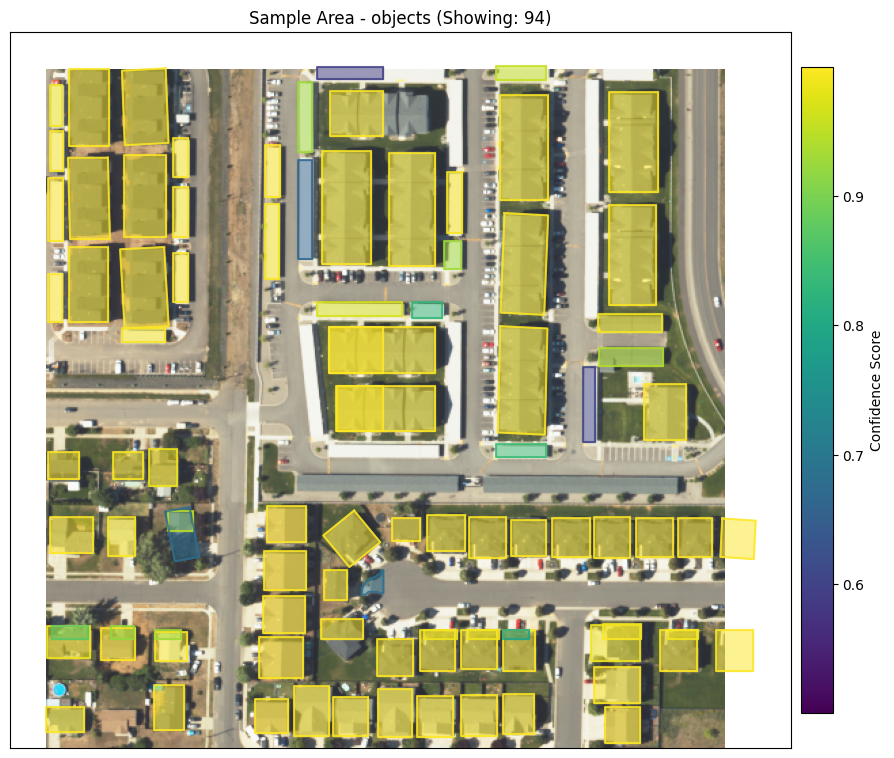

In [1]:
def step10():
    if not CFG["run_pretrained"]:
        print("  disabled in CFG"); return

    extractor = geoai.BuildingFootprintExtractor(model_path="building_footprints_usa.pth")
    gdf = extractor.process_raster(
        TEST_RASTER,
        output_path=os.path.join(WORK, "buildings_maskrcnn.geojson"),
        batch_size=4,
        confidence_threshold=0.5,
        overlap=0.25,
        mask_threshold=0.5,
        min_object_area=100,
        filter_edges=True,
    )
    if gdf is None or len(gdf) == 0:
        print("  no instances returned"); return
    print(f"  building instances: {len(gdf)}")
    reg = extractor.regularize_buildings(gdf, min_area=20, angle_threshold=15)
    reg.to_file(os.path.join(WORK, "buildings_maskrcnn_regularized.geojson"), driver="GeoJSON")
    extractor.visualize_results(TEST_RASTER, gdf=reg, figsize=(12, 12))

    if FINAL_GDF is not None:
        print(f"\n  your U-Net      : {len(FINAL_GDF)} polygons")
        print(f"  pretrained R-CNN: {len(reg)} polygons")
        print("  Different counts are expected: U-Net merges adjacent roofs, Mask R-CNN splits")
        print("  them into instances. Pick the paradigm that matches your downstream question.")
    geoai.empty_cache()


timed(step10, "STEP 10 — Pretrained Mask R-CNN instance segmentation")


def step11():
    if not CFG["run_real_aoi"]:
        print("  disabled (set CFG['run_real_aoi'] = True to run; needs open internet)")
        return
    bbox = (-83.9400, 35.9500, -83.9250, 35.9600)

    items = geoai.pc_stac_search(
        collection="naip",
        bbox=list(bbox),
        time_range="2021-01-01/2023-12-31",
        max_items=3,
    )
    print(f"  STAC items found: {len(items)}")

    aoi_dir = os.path.join(WORK, "aoi")
    tif = geoai.download_naip(bbox=bbox, output_dir=aoi_dir, max_items=1, preview=False)
    print(f"  NAIP: {tif}")

    ovt = os.path.join(aoi_dir, "overture_buildings.geojson")
    geoai.download_overture_buildings(bbox=bbox, output=ovt, overture_type="building")
    print(f"  Overture buildings: {ovt}")
    print(geoai.extract_building_stats(ovt))


    raster = tif[0] if isinstance(tif, (list, tuple)) else tif
    geoai.export_geotiff_tiles(
        in_raster=raster,
        out_folder=os.path.join(aoi_dir, "tiles"),
        in_class_data=ovt,
        tile_size=512,
        stride=256,
    )
    print("  AOI dataset ready — feed it to train_segmentation_model() exactly as in STEP 4.")


timed(step11, "STEP 11 — (optional) Real AOI: Planetary Computer NAIP + Overture Maps labels")


def step12():
    outputs = [f for f in sorted(os.listdir(WORK))
               if f.endswith((".tif", ".geojson", ".png", ".pth"))]
    print("  artifacts produced:")
    for f in outputs:
        print(f"    {os.path.getsize(os.path.join(WORK, f)) / 1e6:8.2f} MB  {f}")

    zip_path = os.path.join(WORK, "geoai_results.zip")
    subprocess.run(
        ["zip", "-qr", zip_path, ".", "-i", "*.geojson", "*.png", "*.tif", "-x", "*tiles*"],
        cwd=WORK, check=False,
    )
    print(f"\n  bundle: {zip_path}")
    if IN_COLAB:
        print("  Download it with:  from google.colab import files; "
              "files.download('%s')" % zip_path)


timed(step12, "STEP 12 — Results summary")

banner("DONE")
print("""
Where to go next
----------------
* Swap the head, keep the code: architecture="deeplabv3plus", encoder_name="efficientnet-b3"
  (or any timm encoder) in train_segmentation_model().
* 4-band NAIP (RGB+NIR): num_channels=4 everywhere; the first conv is auto-adapted.
* Multi-class land cover: geoai.train_segmentation_landcover() + geoai.export_landcover_tiles(),
  with DiceLoss / FocalLoss / TverskyLoss from geoai.landcover_train for class imbalance.
* Instance segmentation you train yourself: geoai.train_MaskRCNN_model() then
  geoai.instance_segmentation(..., vectorize=True).
* Object detection with georeferenced boxes: geoai.train.object_detection() /
  geoai.object_detection(text="cars") for open-vocabulary Grounding DINO.
* Foundation models: geoai.prithvi_inference (NASA/IBM Prithvi), geoai.universat_inference,
  geoai.DINOv3GeoProcessor for embeddings and similarity maps.
* Change detection: geoai.change_detection (torchange backends).
* Deploy: geoai.export_to_onnx() + geoai.onnx_semantic_segmentation(), or the QGIS plugin.

Docs and notebooks: https://opengeoai.org  |  Book: https://book.opengeoai.org
""")